# **Brazilian E-Commerce Comprehensive Analytics Report (Olist Dataset)**

## **Executive Brief & Data Warehouse Blueprint**
This notebook establishes a scalable data engineering pipeline and an analytical deep-dive into the Olist E-commerce ecosystem. Moving beyond flat-file analysis, this workflow transforms 9 isolated datasets into a structured, relational relational database schema using Python, pandas, and SQLite (SQLAlchemy) to mirror real-world data warehousing practices.

---

## **Data Dictionary & Source Schemas**

### 1. Customers Dataset (`olist_customers_dataset.csv`)
*Ties individual customer accounts to geographic locations and unique identity keys.*
* **`customer_id`**: Key that joins to each specific order (unique per order).
* **`customer_unique_id`**: Unique identifier for the actual customer account (tracks repeat purchasers).
* **`customer_zip_code_prefix`**: First 5 digits of customer's zip code.
* **`customer_city`**: Name of the city where the customer is located.
* **`customer_state`**: State abbreviation code.

### 2. Geolocation Dataset (`olist_geolocation_dataset.csv`)
*Provides spatial coordinates for mapping logistics and shipping hubs.*
* **`geolocation_zip_code_prefix`**: First 5 digits of a geographic zip code area.
* **`geolocation_lat`**: Latitude coordinate.
* **`geolocation_lng`**: Longitude coordinate.
* **`geolocation_city`**: Normalized city string.
* **`geolocation_state`**: State code.

### 3. Order Items Dataset (`olist_order_items_dataset.csv`)
*Transactional manifest listing specific line items contained within each order.*
* **`order_id`**: System identifier for the order transaction.
* **`order_item_id`**: Sequential line item number within the same order (e.g., item 1, item 2).
* **`product_id`**: Relational key pointing to the specific product catalog registry.
* **`seller_id`**: Relational key pointing to the merchant registration table.
* **`shipping_limit_date`**: Merchant fulfillment deadline for handling and carrier handover.
* **`price`**: Item-level base price paid by consumer (excluding shipping cost).
* **`freight_value`**: Calculated shipping fees allocated to this specific item.

### 4. Order Payments Dataset (`olist_order_payments_dataset.csv`)
*Financial split information detailing the monetary channels utilized by customers.*
* **`order_id`**: System identifier for the order transaction.
* **`payment_sequential`**: Sequential index if a consumer paid using multiple payment methods.
* **`payment_type`**: Form of transaction payment (e.g., credit_card, boleto, voucher, debit_card).
* **`payment_installments`**: Number of payment installments selected by the buyer.
* **`payment_value`**: Total transaction amount processed through this specific payment stream.

### 5. Order Reviews Dataset (`olist_order_reviews_dataset.csv`)
*Post-delivery qualitative feedback and survey scoring submitted by purchasers.*
* **`review_id`**: Unique identifier assigned to an individual user review submission.
* **`order_id`**: Relational reference connecting back to the targeted order execution.
* **`review_score`**: Integer score mapping consumer satisfaction metrics (Scale 1–5).
* **`review_comment_title`**: Subject headline provided by the customer review.
* **`review_comment_message`**: Text body narrative detailing consumer experience.
* **`review_creation_date`**: Chronological date record when the feedback survey was issued.
* **`review_answer_timestamp`**: Chronological log capturing actual survey form completion.

### 6. Orders Dataset (`olist_orders_dataset.csv`)
*The central logistical master record handling status flags and fulfillment milestones.*
* **`order_id`**: Unique system identifier for the transaction.
* **`customer_id`**: Relational key mapping back to the customer's transactional index.
* **`order_status`**: Operational status flag (e.g., delivered, shipped, canceled, invoiced).
* **`order_purchase_timestamp`**: Precise date and time when the customer checked out.
* **`order_approved_at`**: Log confirming financial payment approval clearance.
* **`order_delivered_carrier_date`**: Log detailing inventory handoff to shipping carrier.
* **`order_delivered_customer_date`**: Actual timestamp showing buyer arrival delivery receipt.
* **`order_estimated_delivery_date`**: Initial commitment target date calculated for delivery.

### 7. Products Dataset (`olist_products_dataset.csv`)
*Item catalog metadata providing precise specifications of warehouse items.*
* **`product_id`**: Unique identification code for a catalog item.
* **`product_category_name`**: Technical category classification in native Portuguese.
* **`product_name_lenght`**: Numeric character length of item title registry.
* **`product_description_lenght`**: Numeric character length of descriptive web documentation.
* **`product_photos_qty`**: Count of high-resolution digital image assets attached to product page.
* **`product_weight_g`**: Deadweight measurement formatted in grams.
* **`product_length_cm`**: Dimension measurement across physical length.
* **`product_height_cm`**: Dimension measurement across physical vertical height.
* **`product_width_cm`**: Dimension measurement across physical dimensional width.

### 8. Sellers Dataset (`olist_sellers_dataset.csv`)
*Merchant registry storing key business location profiles for fulfillment centers.*
* **`seller_id`**: Unique merchant identifier code.
* **`seller_zip_code_prefix`**: Merchant fulfillment warehouse zip location code.
* **`seller_city`**: Operating municipal city base for merchant operations.
* **`seller_state`**: Regional operating state territory code.

### 9. Category Name Translation (`product_category_name_translation.csv`)
*Localization crosswalk mapping specialized labels.*
* **`product_category_name`**: Native Portuguese category title string.
* **`product_category_name_english`**: English localization conversion title string.

***

# **Step 1: Environment Setup & Library Imports**

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***

# **Step 2: Data Loading & Initial Inspection**

In [232]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocations = pd.read_csv("olist_geolocation_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")

In [233]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [234]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [235]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


In [236]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [237]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,9/19/2017 9:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,5/3/2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1/18/2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,8/15/2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2/13/2017 13:57,199.90,18.14


In [238]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [239]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [240]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [241]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [242]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [243]:
geolocations.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [244]:
geolocations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [245]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [246]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [247]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,1/18/2018 0:00,1/18/2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,3/10/2018 0:00,3/11/2018 3:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2/17/2018 0:00,2/18/2018 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,4/21/2017 0:00,4/21/2017 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,3/1/2018 0:00,3/2/2018 10:26


In [248]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [249]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [250]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


***

# **Step 3: Data Cleaning & Transformation**

## **Customers**

In [251]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [252]:
customers.duplicated().sum()

np.int64(0)

NOTE:- There is no NULL and Duplicate Value in customers file.

In [253]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [254]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [255]:
# Converting the Datatype of each column to the appropriate datatype in "Customers" file

customers['customer_id'] = customers['customer_id'].astype('string')
customers['customer_unique_id'] = customers['customer_unique_id'].astype('string')
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str).str.zfill(5)
customers['customer_city'] = customers['customer_city'].astype('category')
customers['customer_state'] = customers['customer_state'].astype('category')

In [256]:
# Now let's datatype after conversion
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               99441 non-null  string  
 1   customer_unique_id        99441 non-null  string  
 2   customer_zip_code_prefix  99441 non-null  object  
 3   customer_city             99441 non-null  category
 4   customer_state            99441 non-null  category
dtypes: category(2), object(1), string(2)
memory usage: 2.7+ MB


## **Orders**

In [257]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [258]:
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [259]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [260]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [261]:
missing_approved_at = orders['order_approved_at'].isnull().sum()
print(f"Number of missing values in 'order_approved_at': {missing_approved_at}")

missing_approved_at = orders['order_delivered_carrier_date'].isnull().sum()
print(f"Number of missing values in 'order_delivered_carrier_date': {missing_approved_at}")

missing_approved_at = orders['order_delivered_customer_date'].isnull().sum()
print(f"Number of missing values in 'order_delivered_customer_date': {missing_approved_at}")

Number of missing values in 'order_approved_at': 160
Number of missing values in 'order_delivered_carrier_date': 1783
Number of missing values in 'order_delivered_customer_date': 2965


### Why We Do Not Delete the Remaining Null (NaT) Values

Even after changing the data types to datetime, `orders.isnull().sum()` still shows:
* **order_approved_at**: 160 nulls
* **order_delivered_carrier_date**: 1,783 nulls
* **order_delivered_customer_date**: 2,965 nulls

#### The Explanation:
1. **They are not data errors:** In a real business warehouse, a missing date simply means that specific step **never happened yet**. For example, an order that was canceled or is still being shipped by the truck will *never* have a customer delivery date.
2. **Why we cannot delete them:** If we delete these rows completely, we accidentally delete rows representing canceled orders, processing orders, and active shipments from our system. This would ruin our overall business KPI accuracy.

In [262]:
orders.duplicated().sum()

np.int64(0)

## **Order_Items**

In [263]:
order_items.duplicated().sum()

np.int64(0)

In [264]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [265]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [266]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,9/19/2017 9:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,5/3/2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1/18/2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,8/15/2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2/13/2017 13:57,199.90,18.14


In [267]:
order_items['order_id'] = order_items['order_id'].astype('string')
order_items['product_id'] = order_items['product_id'].astype('string')
order_items['seller_id'] = order_items['seller_id'].astype('string')
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
# price and freight_value are already float — leave as is

In [268]:
# Now let's check the datatype after conversion
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  string        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  string        
 3   seller_id            112650 non-null  string        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 6.0 MB


## **Products**

In [269]:
# Finding the missing values in the products file
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [270]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [271]:
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products[col].fillna(products[col].median())

In [272]:
# Finding Duplicates in the products file
products.duplicated().sum()

np.int64(0)

In [273]:
# Finsing the datatype of each column in the products file
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [274]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [275]:
products['product_id'] = products['product_id'].astype('string')
products['product_category_name'] = products['product_category_name'].astype('category')

In [276]:
# Now let's check the datatype after conversion
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   product_id                  32951 non-null  string  
 1   product_category_name       32951 non-null  category
 2   product_name_lenght         32341 non-null  float64 
 3   product_description_lenght  32341 non-null  float64 
 4   product_photos_qty          32341 non-null  float64 
 5   product_weight_g            32951 non-null  float64 
 6   product_length_cm           32951 non-null  float64 
 7   product_height_cm           32951 non-null  float64 
 8   product_width_cm            32951 non-null  float64 
dtypes: category(1), float64(7), string(1)
memory usage: 2.0 MB


## **Sellers**

In [277]:
# Finding the missing values in the sellers file
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [278]:
# Finding Duplicates in the sellers file
sellers.duplicated().sum()

np.int64(0)

In [279]:
# Finding Datatype of each column in the sellers file
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [280]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [281]:
sellers['seller_id'] = sellers['seller_id'].astype('string')
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str).str.zfill(5)
sellers['seller_city'] = sellers['seller_city'].astype('category')
sellers['seller_state'] = sellers['seller_state'].astype('category')

In [282]:
# Now let's check the datatype after conversion
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   seller_id               3095 non-null   string  
 1   seller_zip_code_prefix  3095 non-null   object  
 2   seller_city             3095 non-null   category
 3   seller_state            3095 non-null   category
dtypes: category(2), object(1), string(1)
memory usage: 79.2+ KB


## **Geolocations**

In [283]:
# Finding the missing values in the geolocation file
geolocations.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [284]:
# Finding Duplicates in the geolocation file
geolocations.duplicated().sum()

np.int64(269687)

**NOTE** :- In **geolocation** there can be duplicates because there will be planty of people from one area pin code.

In [285]:
# Checking the datatype of each column in the geolocation file
geolocations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [286]:
geolocations.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [287]:
geolocations['geolocation_zip_code_prefix'] = geolocations['geolocation_zip_code_prefix'].astype(str).str.zfill(5)
geolocations['geolocation_city'] = geolocations['geolocation_city'].astype('category')
geolocations['geolocation_state'] = geolocations['geolocation_state'].astype('category')

In [288]:
# Now let's check the datatype after conversion
geolocations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   geolocation_zip_code_prefix  1000163 non-null  object  
 1   geolocation_lat              1000163 non-null  float64 
 2   geolocation_lng              1000163 non-null  float64 
 3   geolocation_city             1000163 non-null  category
 4   geolocation_state            1000163 non-null  category
dtypes: category(2), float64(2), object(1)
memory usage: 26.1+ MB


## **Reviews**

In [289]:
# Finding the missing values in the sellers file
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

**NOTE** :- Here, in **reviews** there are **null values** because there will be customers who don't write an review for the product/order.

In [290]:
# Finding Duplicates in the reviews file
reviews.duplicated().sum()

np.int64(0)

In [291]:
# Checking the datatype of each column in the reviews file
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [292]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,1/18/2018 0:00,1/18/2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,3/10/2018 0:00,3/11/2018 3:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2/17/2018 0:00,2/18/2018 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,4/21/2017 0:00,4/21/2017 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,3/1/2018 0:00,3/2/2018 10:26


In [293]:
reviews['review_id'] = reviews['review_id'].astype('string')
reviews['order_id'] = reviews['order_id'].astype('string')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

In [294]:
# Now let's check the datatype after conversion
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  string        
 1   order_id                 99224 non-null  string        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(2), string(2)
memory usage: 5.3+ MB


## **Payments**

In [295]:
# Finding the missing values in the payments file
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [296]:
# Finding Duplicates in the payments file
payments.duplicated().sum()

np.int64(0)

In [297]:
# Checking the datatype of each column in the payments file
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [298]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [299]:
payments['order_id'] = payments['order_id'].astype('string')
payments['payment_type'] = payments['payment_type'].astype('category')

In [300]:
# Now let's check the datatype after conversion
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   order_id              103886 non-null  string  
 1   payment_sequential    103886 non-null  int64   
 2   payment_type          103886 non-null  category
 3   payment_installments  103886 non-null  int64   
 4   payment_value         103886 non-null  float64 
dtypes: category(1), float64(1), int64(2), string(1)
memory usage: 3.3 MB


## **Category**

In [301]:
# Finding the missing values in the category file
category.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [302]:
# Finding Duplicates in the category file
category.duplicated().sum()

np.int64(0)

In [303]:
# Checking the datatype of each column in the payments file
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [304]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


***

# **Step 4: Export for SQL and Power BI**

In [305]:
import os
import pandas as pd
from sqlalchemy import create_engine

tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "sellers": sellers,
    "geolocations": geolocations,
    "reviews": reviews,
    "payments": payments,
    "category_translation": category
}


os.makedirs("data/clean", exist_ok=True)
for name, df in tables.items():
    csv_path = f"data/clean/{name}_clean.csv"
    df.to_csv(csv_path, index=False)
    print(f"✓ Backup CSV saved: {csv_path}")



USER = "root"
PASSWORD = "3463"  
HOST = "localhost"
PORT = "3306"
DATABASE = "Brazilian_E_Commerce_Database"

connection_string = f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print(f"\nConnecting to MySQL Server and uploading to database '{DATABASE}'...")


for name, df in tables.items():
    df.to_sql(
        name=name,
        con=engine,
        if_exists="replace",
        index=False,
        chunksize=2000
    )
    print(f"✓ Table '{name}' uploaded — {df.shape[0]:,} rows.")

print("\n✓ All 9 tables successfully pushed into MySQL Workbench.")

✓ Backup CSV saved: data/clean/customers_clean.csv
✓ Backup CSV saved: data/clean/orders_clean.csv
✓ Backup CSV saved: data/clean/order_items_clean.csv
✓ Backup CSV saved: data/clean/products_clean.csv
✓ Backup CSV saved: data/clean/sellers_clean.csv
✓ Backup CSV saved: data/clean/geolocations_clean.csv
✓ Backup CSV saved: data/clean/reviews_clean.csv
✓ Backup CSV saved: data/clean/payments_clean.csv
✓ Backup CSV saved: data/clean/category_translation_clean.csv

Connecting to MySQL Server and uploading to database 'Brazilian_E_Commerce_Database'...
✓ Table 'customers' uploaded — 99,441 rows.
✓ Table 'orders' uploaded — 99,441 rows.
✓ Table 'order_items' uploaded — 112,650 rows.
✓ Table 'products' uploaded — 32,951 rows.
✓ Table 'sellers' uploaded — 3,095 rows.
✓ Table 'geolocations' uploaded — 1,000,163 rows.
✓ Table 'reviews' uploaded — 99,224 rows.
✓ Table 'payments' uploaded — 103,886 rows.
✓ Table 'category_translation' uploaded — 71 rows.

✓ All 9 tables successfully pushed into M

In [306]:
# Checking all the tables in the database
pd.read_sql("SHOW TABLES;", con=engine)

,Tables_in_brazilian_e_commerce_database
0,category_translation
1,customers
2,geolocations
3,order_items
4,orders
5,payments
6,products
7,reviews
8,sellers


***

# **Step 5: EDA & Visualization**

In [307]:
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Revenue Trend**

In [308]:
import os

DATA_DIR = r"C:\Users\Asus\OneDrive\Desktop\Portfolio Projects\Retail\Self\SQL Output"

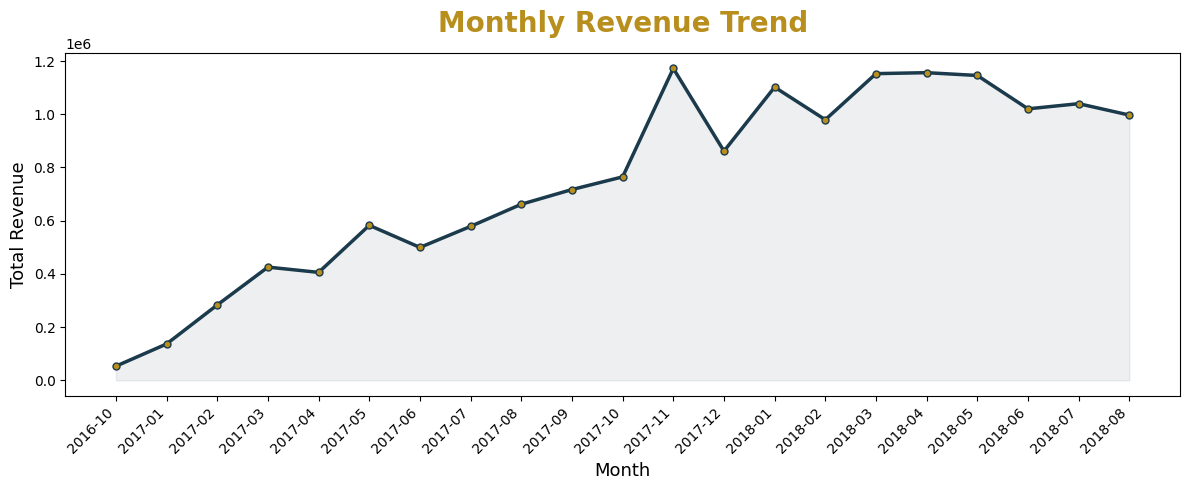

In [309]:
df1 = pd.read_csv(os.path.join(DATA_DIR, "1__Monthly_revenue_trend.csv"))
df1 = df1[df1['Total_Orders'] > 50]

plt.figure(figsize=(12, 5))

plt.plot('Month', 'Total_Revenue', data=df1, color='#1B3A4B', marker='o',
         markersize=5, markerfacecolor='#B88E1D', linewidth=2.5)
plt.fill_between(df1['Month'], df1['Total_Revenue'], alpha=0.08, color='#1B3A4B')

plt.title('Monthly Revenue Trend', color='#B88E1D', size=20, weight='bold', pad=15)
plt.xlabel('Month', size=13)
plt.ylabel('Total Revenue', size=13)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **2. Top 10 Category**

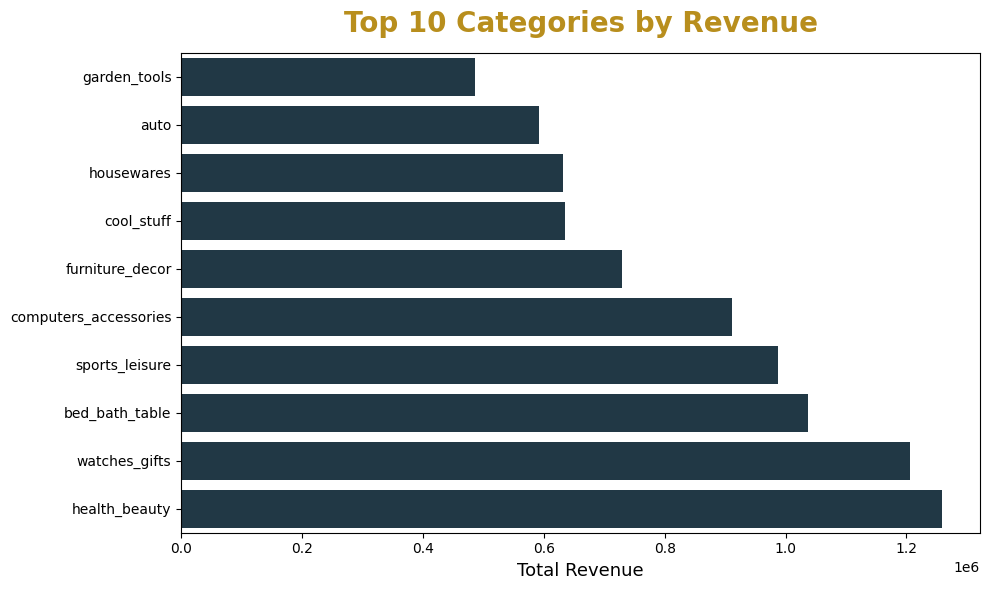

In [310]:
df2 = pd.read_csv(os.path.join(DATA_DIR, "2__Top_10_categories_by_revenue.csv"))
df2 = df2.sort_values('total_revenue')

plt.figure(figsize=(10, 6))

sns.barplot(data=df2, x='total_revenue', y='category', color='#1B3A4B')

plt.title('Top 10 Categories by Revenue', color='#B88E1D', size=20, weight='bold', pad=15)
plt.xlabel('Total Revenue', size=13)
plt.ylabel('')

plt.tight_layout()
plt.show()

## **3. Delivery Delay vs Review Score**

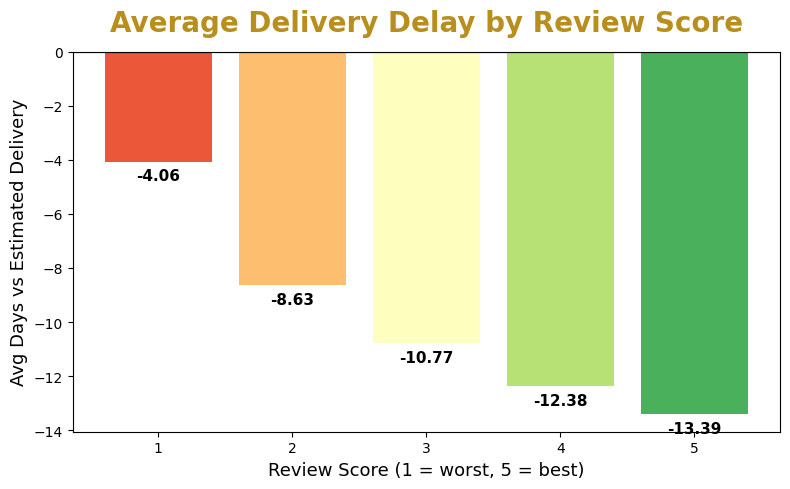

In [311]:
df6 = pd.read_csv(os.path.join(DATA_DIR, "6__Delivery_delay_vs_review_score.csv"))

plt.figure(figsize=(8, 5))

bars = plt.bar(df6['review_score'].astype(str), df6['avg_delay_days'],
               color=sns.color_palette('RdYlGn', len(df6)))

plt.title('Average Delivery Delay by Review Score', color='#B88E1D', size=20, weight='bold', pad=15)
plt.xlabel('Review Score (1 = worst, 5 = best)', size=13)
plt.ylabel('Avg Days vs Estimated Delivery', size=13)
plt.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, df6['avg_delay_days']):
    plt.text(bar.get_x() + bar.get_width()/2, val - 0.7, f'{val}',
              ha='center', size=11, weight='bold')

plt.tight_layout()
plt.show()

### **Pearson's r between delay days and review score**

In [323]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df6['avg_delay_days'], df6['review_score'])
print(f"Correlation: {corr:.2f}, p-value: {p_value:.4f}")

Correlation: -0.96, p-value: 0.0105


**NOTE** - Average review score shows a strong negative correlation with delivery delay (r = -0.96) across delivery outcome groups — as delay increases, satisfaction drops sharply and consistently

## **4. Payment Method Breakdown**

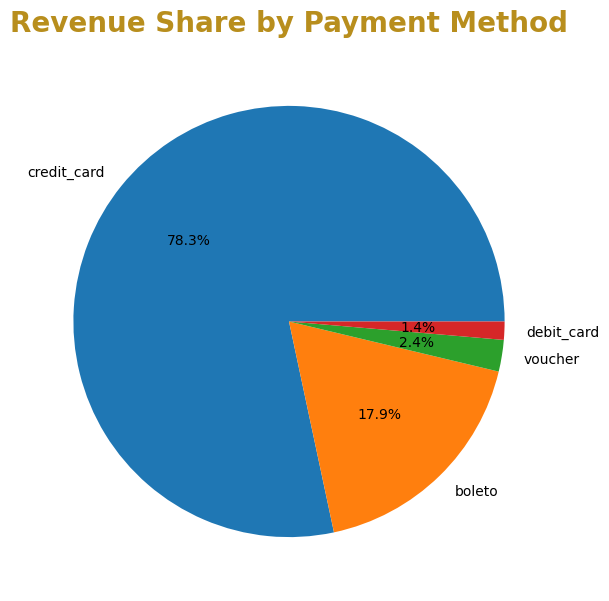

In [312]:
df7 = pd.read_csv(os.path.join(DATA_DIR, "7__Payment_method_breakdown_by_order_value_tier.csv"))
df7 = df7[df7['payment_type'] != 'not_defined']   # only 3 rows worth R$0 — not a real category

plt.figure(figsize=(7, 7))

plt.pie(df7['total_value'], labels=df7['payment_type'], autopct='%1.1f%%')

plt.title('Revenue Share by Payment Method', color='#B88E1D', size=20, weight='bold', pad=15)

plt.show()

## **5. Revenue by State**

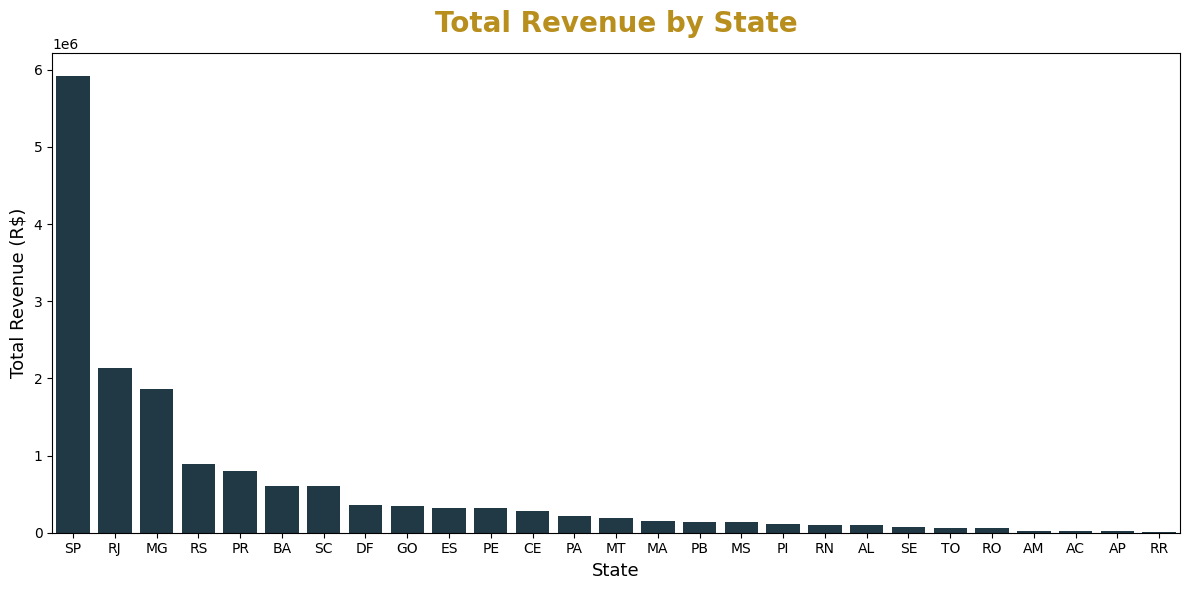

In [313]:
df8 = pd.read_csv(os.path.join(DATA_DIR, "8__Revenue_by_state.csv"))
df8 = df8.sort_values('total_revenue', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(data=df8, x='customer_state', y='total_revenue', color='#1B3A4B')

plt.title('Total Revenue by State', color='#B88E1D', size=20, weight='bold', pad=15)
plt.xlabel('State', size=13)
plt.ylabel('Total Revenue (R$)', size=13)

plt.tight_layout()
plt.show()

## **6. Order Count by Status**

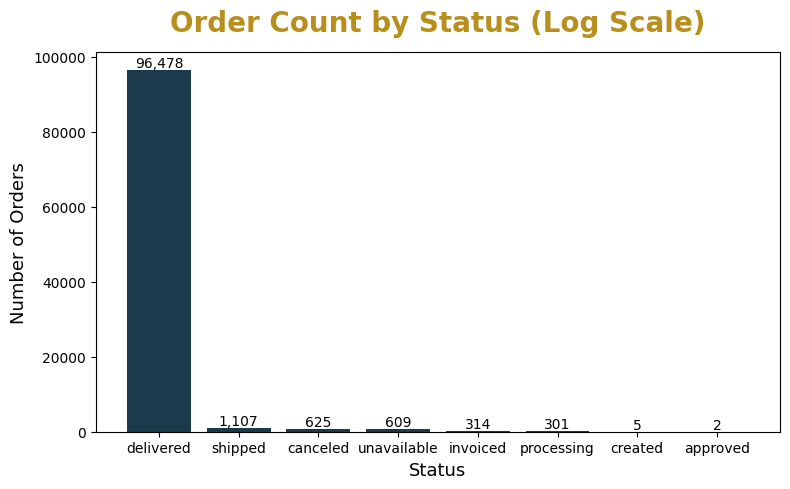

In [314]:
df10 = pd.read_csv(os.path.join(DATA_DIR, "10__Order_count_by_status.csv"))
df10 = df10.sort_values('num_orders', ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(df10['order_status'], df10['num_orders'], color='#1B3A4B')

plt.title('Order Count by Status (Log Scale)', color='#B88E1D', size=20, weight='bold', pad=15)
plt.xlabel('Status', size=13)
plt.ylabel('Number of Orders', size=13)

for index, value in enumerate(df10['num_orders']):
    plt.text(index, value, f"{value:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **Step 6. Customer Segmentation (RFM Analysis)**

In [315]:
import pandas as pd

orders_and_payments = pd.merge(orders, payments, on="order_id")

rfm_base = pd.merge(orders_and_payments, customers, on="customer_id")

latest_purchase_date = rfm_base["order_purchase_timestamp"].max()

snapshot_date = latest_purchase_date + pd.Timedelta(days=1)

grouped_customers = rfm_base.groupby("customer_unique_id")


rfm = pd.DataFrame()

last_purchase_per_customer = grouped_customers["order_purchase_timestamp"].max()

rfm["recency"] = (snapshot_date - last_purchase_per_customer).dt.days
rfm["frequency"] = grouped_customers["order_id"].nunique()
rfm["monetary"] = grouped_customers["payment_value"].sum()


rfm = rfm.reset_index()

rfm["R_score"] = pd.qcut(rfm["recency"], q=4, labels=[4, 3, 2, 1])

frequency_ranked = rfm["frequency"].rank(method="first")
rfm["F_score"] = pd.qcut(frequency_ranked, q=4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["monetary"], q=4, labels=[1, 2, 3, 4])


rfm["RFM_segment"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)


rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


In [316]:
rfm.to_sql(name="customer_rfm", con=engine, if_exists="replace", index=False)

-1

In [317]:
# 1. Top 10 Spenders (Highest Monetary Value)
highest_spenders = rfm.sort_values(by="monetary", ascending=False).head(10)

# 2. Top 10 Most Frequent Buyers
frequent_buyers = rfm.sort_values(by="frequency", ascending=False).head(10)

# 3. Most "At Risk" Customers (Bought a long time ago, but spent a lot of money)
# Look for low Recency but high Monetary
at_risk_customers = rfm.sort_values(
    by=["recency", "monetary"], ascending=[False, False]
).head(10)

In [318]:
highest_spenders

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_segment
3826,0a0a92112bd4c708ca5fde585afaa872,384,1,13664.08,2,1,4,214
26456,46450c74a0d8c5ca9395da1daac6c120,61,3,9553.02,4,4,4,444
81961,da122df9eeddfedc1dc1f5349a1a690c,565,2,7571.63,1,4,4,144
44447,763c8b1c9c68a0229c42c9fc6f662b93,95,1,7274.88,4,2,4,424
82807,dc4802a71eae9be1dd28f5d788ceb526,612,1,6929.31,1,4,4,144
26205,459bef486812aa25204be022145caa62,84,1,6922.21,4,2,4,424
95805,ff4159b92c40ebe40454e3e6a7c35ed6,511,1,6726.66,1,4,4,144
24121,4007669dec559734d6f53e029e360987,328,1,6081.54,2,1,4,214
35070,5d0a2980b292d049061542014e8960bf,98,1,4809.44,4,2,4,424
89687,eebb5dda148d3893cdaf5b5ca3040ccb,547,1,4764.34,1,4,4,144


In [319]:
frequent_buyers

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_segment
52972,8d50f5eadf50201ccdcedfb9e2ac8455,58,17,927.63,4,4,4,444
23472,3e43e6105506432c953e165fb2acf44c,232,9,1172.66,3,4,4,344
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,246,7,959.01,3,4,4,344
37797,6469f99c1f9dfae7733b25662e7f1782,112,7,758.83,4,4,4,444
76081,ca77025e7201e3b30c44b472ff346268,139,7,1122.72,4,4,4,444
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,267,6,944.21,3,4,4,344
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,651,6,110.72,1,4,3,143
37585,63cfc61cee11cbe306bff5857d00bfe4,143,6,826.32,4,4,4,444
82882,dc813062e0fc23409cd255f7f53c7074,56,6,1094.63,4,4,4,444
83539,de34b16117594161a6a89c50b289d35a,273,6,660.94,2,4,4,244


In [320]:
at_risk_customers

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_segment
69096,b7d76e111c89f7ebf14761390f0f7d17,773,1,136.23,1,3,3,133
27245,4854e9b3feff728c13ee5fc7d1547e92,773,1,75.06,1,2,2,122
238,009b0127b727ab0ba422f6d9604487c7,765,1,40.95,1,1,1,111
5521,0eb1ee9dba87f5b36b4613a65074337c,745,1,109.34,1,1,3,113
17870,2f64e403852e6893ae37485d5fcacdaf,745,1,39.09,1,1,1,111
26298,45d9410bc1f3c6e36dea41d8f823ada6,744,1,659.41,1,2,4,124
51816,89ff26f9d000b4a6d0f6e8c513f1cf08,744,1,451.44,1,3,4,134
16091,2ad10f49ef1f061d5f6739c89d3ade68,744,1,398.12,1,1,4,114
52931,8d36e7e56a9f8044df728e9cbf5a3eaf,744,1,319.00,1,3,4,134
15227,28706b8dc0fe2a95fbcec1e53253d8e4,744,1,277.81,1,1,4,114
